In [1]:
%load_ext autoreload
%autoreload 2
%load_ext line_profiler
%matplotlib widget
    
import moabb
from moabb.datasets import *
from moabb.paradigms import P300
from hoda.hoda import HODA
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from mne.viz import plot_topomap
from sklearn.decomposition import PCA
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis
from sklearn.metrics import roc_auc_score
from sklearn.manifold import TSNE
from mne.decoding import Scaler
from mne import combine_evoked

In [2]:
from moabb.paradigms import P300
from moabb.datasets import BNCI2014008, BNCI2014009, EPFLP300
plt.style.use('default')

tmin = -0.2
tmax=1.0
fmin=0.5
fmax = 32
sfreq = 64

paradigm = P300(resample=sfreq, tmin=tmin, tmax=tmax, fmin=fmin, fmax=fmax)
dataset = BNCI2014008()
epochs, labels, meta = paradigm.get_data(
    dataset=dataset, 
    subjects=[1],
    return_epochs=True
)


Not setting metadata
4200 matching events found
No baseline correction applied
Not setting metadata
4200 matching events found
No baseline correction applied


In [3]:
import tensorly.decomposition
import matplotlib.pyplot as plt
import tensorly as tl

tl.set_backend('cupy')

X = epochs.get_data()
y = labels

X.shape

(4200, 8, 77)

In [18]:
from hoda.hoda import BTTDA
from sklearn.pipeline import Pipeline
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis
from mne.decoding import Scaler
import warnings
warnings.filterwarnings("ignore")

n_blocks=16
bttda = BTTDA(
    n_blocks=n_blocks,
    hoda_params=dict(
            rank=None,
            max_iter=128,
            tol=1e-16,
            init ='svd',
            shrinkage=('lw','lw'),
            toeplitz=None,
            obj='rt',
            solver='lanczos',
            taper=False,
            keep_train_info=False,
            verbose=True,
            lasso=False,
            prune=True,
            prune_pvalue=0.05,
            combine_pvalue='fisher'
    ),
    var_thresh = .50,
    deflate_transform=False,
    keep_train_info=True,
    verbose=True)                   

bttda.fit(X,y)

Fitting block 1/16...
Initializing factors...
Fitting discriminative Tucker model...


  0%|          | 0/128 [00:00<?, ?it/s]

Fitted Tucker model of rank [8, 5] ...

Fitting block 2/16...
Initializing factors...
Fitting discriminative Tucker model...


  0%|          | 0/128 [00:00<?, ?it/s]

Fitted Tucker model of rank [5, 4] ...

Fitting block 3/16...
Initializing factors...
Fitting discriminative Tucker model...


...

  0%|          | 0/128 [00:00<?, ?it/s]

Fitted Tucker model of rank [2, 2] ...

Fitting block 7/16...
Initializing factors...
Fitting discriminative Tucker model...


  0%|          | 0/128 [00:00<?, ?it/s]

Fitted Tucker model of rank [2, 2] ...



BTTDA(hoda_params={'combine_pvalue': 'fisher', 'init': 'svd',
                   'keep_train_info': False, 'lasso': False, 'max_iter': 128,
                   'obj': 'rt', 'prune': True, 'prune_pvalue': 0.05,
                   'rank': None, 'shrinkage': ('lw', 'lw'), 'solver': 'lanczos',
                   'taper': False, 'toeplitz': None, 'tol': 1e-16,
                   'verbose': True},
      keep_train_info=True, n_blocks=16, var_thresh=0.5, verbose=True)

In [19]:
bttda.train_info_

,mse,explained,f_stat_defl,f_stat
block,,,,
0,1.187413e-10,0.291719,0.011201,0.011201
1,1.098667e-10,0.389638,0.004619,0.004534
2,1.078825e-10,0.424802,0.014282,0.007753
3,1.021615e-10,0.466538,0.009255,0.001138
4,1.005302e-10,0.479340,0.016222,0.000311
5,9.762995e-11,0.499955,0.009751,0.000364
6,9.592935e-11,0.511706,0.017882,0.000168


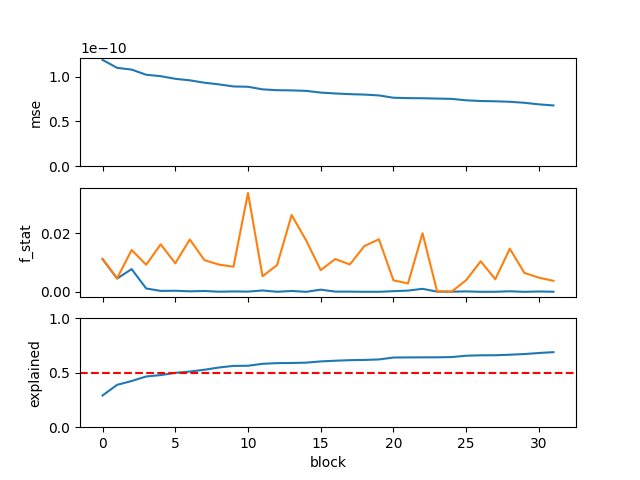

In [16]:
if bttda.keep_train_info:
    fig, axs = plt.subplots(3,1, sharex=True)
    sns.lineplot(data=bttda.train_info_,  x="block", y="mse", ax=axs[0])
    axs[0].set_ylim([0,None])
    sns.lineplot(data=bttda.train_info_,  x="block", y="f_stat", ax=axs[1])
    sns.lineplot(data=bttda.train_info_,  x="block", y="f_stat_defl", ax=axs[1])
    sns.lineplot(data=bttda.train_info_,  x="block", y="explained", ax=axs[2])
    axs[2].set_ylim([0,1])
    axs[2].axhline(.5, color='red', linestyle='--')

In [7]:
"""
fig, axs = plt.subplots(n_blocks, 2, figsize=(8,16))
for b in range(len(bttda.blocks_)):
    for k in range(2):
        scatter_w = tl.to_numpy(bttda.blocks_[b].scatter_w_[k])
        vmax = np.max(np.abs(scatter_w))
        sns.heatmap(scatter_w, cmap='BrBG',
                    vmin=-vmax, vmax=vmax, ax=axs[b,k])    
        axs[b,k].set_aspect('equal')
"""

"\nfig, axs = plt.subplots(n_blocks, 2, figsize=(8,16))\nfor b in range(len(bttda.blocks_)):\n    for k in range(2):\n        scatter_w = tl.to_numpy(bttda.blocks_[b].scatter_w_[k])\n        vmax = np.max(np.abs(scatter_w))\n        sns.heatmap(scatter_w, cmap='BrBG',\n                    vmin=-vmax, vmax=vmax, ax=axs[b,k])    \n        axs[b,k].set_aspect('equal')\n"

Not setting metadata
700 matching events found
No baseline correction applied
0 projection items activated
combining channels using "mean"


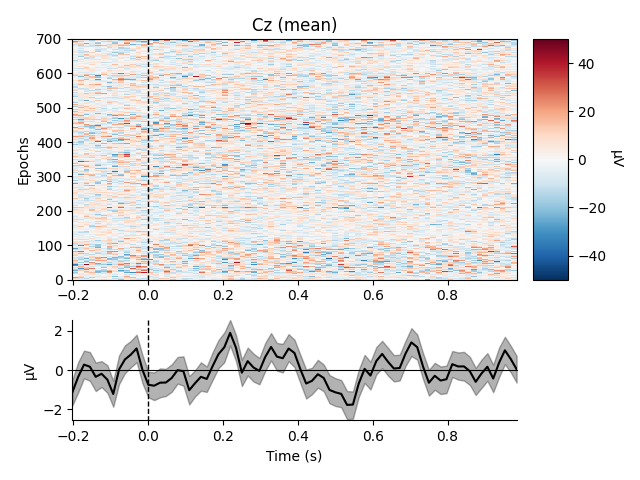

NOTE: pick_channels() is a legacy function. New code should use inst.pick(...).
NOTE: pick_channels() is a legacy function. New code should use inst.pick(...).
No projector specified for this dataset. Please consider the method self.add_proj.
NOTE: pick_channels() is a legacy function. New code should use inst.pick(...).


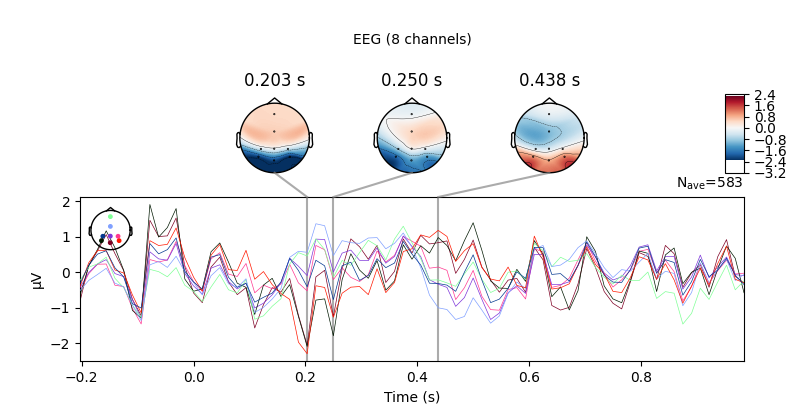

In [8]:
image_args=dict(vmin=-50, vmax=50,picks=['Cz'], combine='mean')
epochs['Target'].plot_image(**image_args)

joint_args=dict(ts_args=dict(ylim=dict(
    #eeg=[-3,3]
)))
target = epochs['Target'].average()
non_target = epochs['NonTarget'].average()
contrast = combine_evoked([target,non_target], weights=[1,-1])
_ = contrast.plot_joint(**joint_args)

In [10]:
from mne import combine_evoked
from hoda.hoda import mse

epochs_defl = epochs.copy()
epochs_rec = epochs.copy()
epochs_rec._data = np.zeros_like(epochs_rec.get_data())
for b in range(min(len(bttda.blocks_),16)):
    epochs_block_rec = epochs.copy()
    epochs_block_rec._data = tl.to_numpy(bttda.blocks_[b].inv_transform(bttda.blocks_[b].transform(epochs_defl.get_data())))
    epochs_defl._data -= epochs_block_rec._data
    epochs_rec._data += epochs_block_rec._data
    
    #target_block_rec = epochs_block_rec['Target'].average()
    #non_target_block_rec = epochs_block_rec['NonTarget'].average()
    #contrast_block_rec = combine_evoked([target_block_rec,non_target_block_rec], weights=[1,-1])
    #_ = contrast_block_rec.plot_joint(**joint_args)


Not setting metadata
700 matching events found
No baseline correction applied
0 projection items activated
combining channels using "mean"


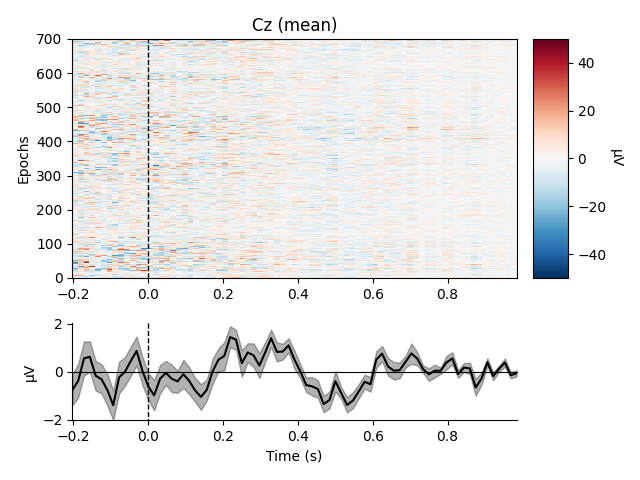

NOTE: pick_channels() is a legacy function. New code should use inst.pick(...).
NOTE: pick_channels() is a legacy function. New code should use inst.pick(...).
No projector specified for this dataset. Please consider the method self.add_proj.
NOTE: pick_channels() is a legacy function. New code should use inst.pick(...).


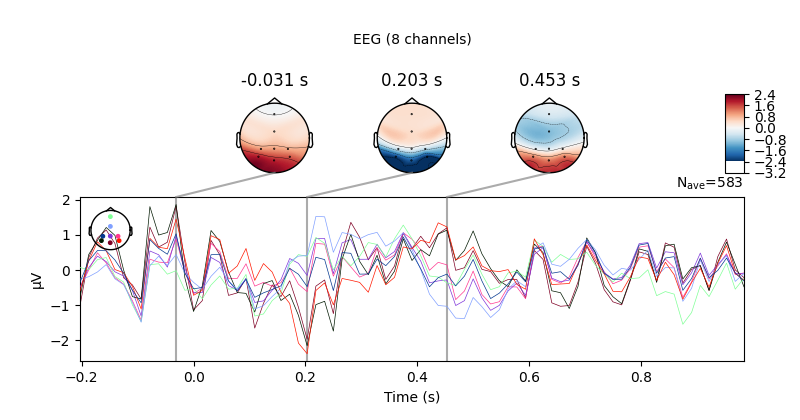

In [11]:
epochs_rec['Target'].plot_image(**image_args)

target_rec = epochs_rec['Target'].average()
non_target_rec = epochs_rec['NonTarget'].average()
contrast_rec = combine_evoked([target_rec,non_target_rec], weights=[1,-1])
_ = contrast_rec.plot_joint()

No projector specified for this dataset. Please consider the method self.add_proj.
NOTE: pick_channels() is a legacy function. New code should use inst.pick(...).


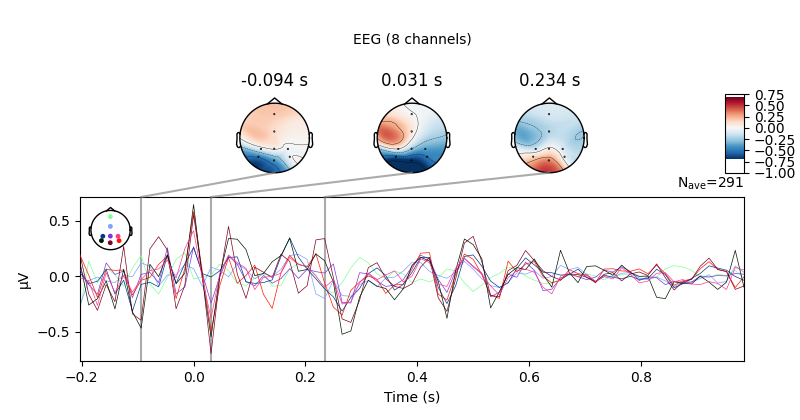

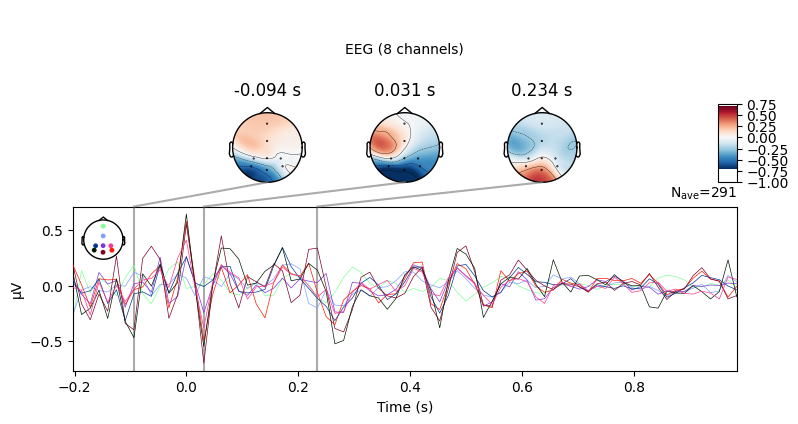

In [12]:
contrast_contrast_rec =  combine_evoked([contrast,contrast_rec], weights=[1,-1])
contrast_contrast_rec.plot_joint()

In [ ]:
Xt = bttda.transform(X)

In [ ]:
import scipy.stats
import seaborn as sns
import math

samples = []
for c in bttda.classes_:
    samples.append(tl.to_numpy(Xt)[y==c])
F,p = scipy.stats.f_oneway(*samples, axis=0)
p = np.nan_to_num(p, nan=1)
fig, ax = plt.subplots(1,1)
plt.bar(np.arange(F.size),F.flatten())
n_params=0
plt.axvline(n_params-.5, color='red')
for b in bttda.blocks_:
    n_params+=math.prod(b.rank_)
    plt.axvline(n_params-.5, color='red')


In [ ]:
from sklearn.manifold import TSNE
import math
from sklearn.decomposition import PCA

order = np.argsort(-F.flatten())
Xt_viz = Xt.reshape((Xt.shape[0],-1))[:,order[:3]]
Xt_viz = tl.to_numpy(Xt.reshape((Xt.shape[0],-1)))
if Xt_viz.shape[-1] > 3:
    decomp  = PCA(n_components=min(3, math.prod(Xt.shape[1:])))
    #decomp  = TSNE(n_components=min(3, math.prod(Xt.shape[1:])), n_jobs=-1)
    Xt_viz = decomp.fit_transform(Xt_viz)


In [ ]:
import re, seaborn as sns
import numpy as np

from matplotlib import pyplot as plt
from mpl_toolkits.mplot3d import Axes3D
from matplotlib.colors import ListedColormap

# axes instance
fig = plt.figure()
ax = Axes3D(fig)
fig.add_axes(ax)

cmap = {'Target': '#e28743', 'NonTarget': '#1e81b0'}
c = np.vectorize(cmap.get)(y)
sc = ax.scatter(Xt_viz[:,0],Xt_viz[:,1],Xt_viz[:,2], c=c)

In [ ]:
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis, QuadraticDiscriminantAnalysis
from sklearn.metrics import roc_auc_score
import pandas as pd
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegressionCV

Xt_flat = tl.to_numpy(Xt.reshape((Xt.shape[0],-1)))
Xt_flat = StandardScaler().fit_transform(Xt_flat)
logreg = LogisticRegressionCV(Cs=10, penalty='l1', solver='liblinear', class_weight='balanced', scoring='roc_auc', n_jobs=-1)
logreg.fit(Xt_flat, y)
score_pred = logreg.decision_function(Xt_flat)


df = pd.DataFrame(dict(score=score_pred,y=y))
g = sns.displot(df, x='score', hue='y')
plt.axvline(0, color='red')
print(roc_auc_score(y,score_pred))

fig, ax = plt.subplots(1,1)
_ = ax.bar(np.arange(Xt_flat.shape[1]), np.abs(logreg.coef_.squeeze()))
n_params=0
plt.axvline(n_params-.5, color='red')
for b in bttda.blocks_:
    n_params+=math.prod(b.rank_)
    plt.axvline(n_params-.5, color='red')

In [ ]:
import matplotlib as mpl
from matplotlib.colors import LinearSegmentedColormap, ListedColormap
color1 = (239, 85, 19)
color2 = (249, 193, 52)

cmap_res=256
vals = np.ones((cmap_res, 4))
for i in range(len(color1)):
    vals[:cmap_res//2,i] = np.linspace(1,color2[i]/256,cmap_res//2)[::-1]
    vals[cmap_res//2:,i] = np.linspace(1,color1[i]/256,cmap_res//2)

cmap_div = ListedColormap(vals)

vals = np.ones((cmap_res, 4))
for i in range(len(color1)):
    vals[:,i] = np.linspace(1,color1[i]/256,cmap_res)
cmap_lin = ListedColormap(vals)
darkgray = (.3,.3,.3)

In [ ]:
import math
from matplotlib.patches import Rectangle
p = 0
n_blocks = 16
col_wrap=4
n_rows = n_blocks//col_wrap
fig, axs= plt.subplots(col_wrap,n_rows, sharex=True, sharey=True)
axs = axs.flatten()
vmax = np.max(np.abs(logreg.coef_[:n_blocks]))
for bi,b in enumerate(bttda.blocks_[:n_blocks]):
    shape = b.rank_
    n_param = math.prod(shape)
    coef = logreg.coef_[:,p:p+n_param]
    p+=n_param
    coef = np.abs(coef.reshape(shape))
    im = axs[bi].imshow(coef, vmin=0, vmax=vmax, cmap=cmap_lin)
    axs[bi].set_xlim([-1,7])
    axs[bi].set_ylim([-1,9])
    axs[bi].set_axis_off()
    axs[bi].add_patch(Rectangle((-.5,-.5), shape[1], shape[0], edgecolor = darkgray,
             fill=False,linewidth=.7))
    axs[bi].set_aspect('equal')
cbar_ax = fig.add_axes([0.85, 0.15, 0.05, 0.7])
cbar_ax.set_axis_off()
fig.colorbar(im, cax=cbar_ax)
fig.set_size_inches(5*0.5,3*0.5)
fig.tight_layout()
fig.subplots_adjust(wspace=-.7, hspace=-.3)
fig.savefig('feature_importance.pgf', bbox_inches='tight', pad_inches=0, dpi=1000)

In [ ]:
fig, ax = plt.subplots(1,1)
ax.plot(bttda.train_info_['mse'], color='#ef5513')
ax.set_xlabel('Number of blocks')
ax.set_ylabel('MSE')
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.set_xlim([0,64])
ax.set_xticks([0,32,64])
ax.set_ylim([0,None])


ax.xaxis.label.set_color(darkgray)        #setting up X-axis label color to yellow
ax.yaxis.label.set_color(darkgray)         #setting up Y-axis label color to blue
ax.tick_params(axis='x', colors=darkgray)    #setting up X-axis tick color to red
ax.tick_params(axis='y', colors=darkgray)  #setting up Y-axis tick color to black
ax.spines['left'].set_color(darkgray)        # setting up Y-axis tick color to red
ax.spines['bottom'].set_color(darkgray) 

fig.set_size_inches(5*0.5,3*0.5)


fig.savefig('mse.pgf', bbox_inches='tight', pad_inches=0)